In [22]:
import pandas as pd
import random
from openai import OpenAI


In [23]:
distory = pd.read_csv("./data/DisasterStory.csv")

In [24]:
distory.columns

Index(['DisNo.', 'Disaster Type', 'Country', 'Locations', 'nNews', 'start_dt',
       'key information', 'severity', 'key drivers',
       'main impacts, exposure, and vulnerability',
       'likelihood of multi-hazard risks',
       'best practices for managing this risk',
       'recommendations and supportive measures for recovery', 'llama graph'],
      dtype='object')

In [85]:
new_df[["Triplet",	"Disaster Type", 	"Storyline", 	"Expert_1", 	"Expert_2", 	"Expert_3", 	"Expert_4", 	"Expert_5", 	"Expert_6"]].to_excel("./data/triplet_expert_val.xlsx", index=False, engine='openpyxl')

In [10]:
import pandas as pd
import random

# Assume `distory` is your DataFrame
# Create a list to store the new dataset
new_data = []

# Iterate over each disaster type
for disaster_type, group in distory.groupby('Disaster Type'):
    for _, row in group.iterrows():
        # Extract triplets
        triplets = eval(row['llama graph'])  # Assuming 'llama graph' is a string representation of a list
        
        # Concatenate storyline text, converting each element to a string and handling missing values
        storyline = ' '.join([
            str(row['key information'] or ''),
            str(row['severity'] or ''),
            str(row['key drivers'] or ''),
            str(row['main impacts, exposure, and vulnerability'] or ''),
            str(row['likelihood of multi-hazard risks'] or ''),
            str(row['best practices for managing this risk'] or ''),
            str(row['recommendations and supportive measures for recovery'] or '')
        ])
        
        # Add entries to the new data list
        for triplet in triplets:
            new_data.append((triplet, disaster_type, storyline))

# Randomly sample 1000 triplets if there are more than 1000
if len(new_data) > 1000:
    new_data = random.sample(new_data, 1000)

# Create a new DataFrame
new_df = pd.DataFrame(new_data, columns=['Triplet', 'Disaster Type', 'Storyline'])

In [12]:
new_df["Disaster Type"].value_counts()

Disaster Type
Flood                               335
Storm                               252
Road                                 81
Earthquake                           64
Mass movement (wet)                  39
Wildfire                             37
Epidemic                             30
Fire (Miscellaneous)                 20
Explosion (Industrial)               19
Air                                  18
Explosion (Miscellaneous)            16
Volcanic activity                    16
Rail                                 13
Collapse (Miscellaneous)             11
Extreme temperature                  11
Water                                 8
Fire (Industrial)                     7
Drought                               7
Glacial lake outburst flood           5
Collapse (Industrial)                 4
Industrial accident (General)         3
Mass movement (dry)                   2
Miscellaneous accident (General)      1
Gas leak                              1
Name: count, dtype: int64

In [7]:
new_df = pd.read_csv("./data/triplet_validationDB.csv")

In [8]:
new_df

,Triplet,Disaster Type,Storyline,gpt-oss-120b_classification,gpt-oss-120b_sentence,llama-3.3-70b-instruct_classification,llama-3.3-70b-instruct_sentence,mistral-small-3.2-24b_classification,mistral-small-3.2-24b_sentence
0,"('nipah virus', 'causes', 'epidemic')",Epidemic,An epidemic event related to the Nipah virus o...,Deductible: True,"Supporting sentence(s): ""The main cause of t...",- Deductible: True,"- Supporting sentence(s): - ""An epidemic eve...",- Deductible: True,"- Supporting sentence(s): - ""The main cause of..."
1,"('flooding', 'causes', 'fatalities')",Storm,"A storm, Typhoon Kalmaegi, occurred in norther...",- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Fatalities: At ..."
2,"('heavy rain', 'causes', 'flooding')",Flood,Heavy rain and flooding hit Rio de Janeiro sta...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and ...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and fl..."
3,"('early intervention', 'prevents', 'casualties')",Flood,"A flood disaster occurred in South Africa, spe...",- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None
4,"('landslide', 'causes', 'economic damage')",Mass movement (wet),A landslide (Mass movement wet) occurred in Re...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""The economic da...",- Deductible: True,"- Supporting sentence(s): - ""The economic dama..."
...,...,...,...,...,...,...,...,...,...
995,"('flooding', 'causes', 'water-logging')",Storm,A storm event occurred in various locations in...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Effects on comm...",- Deductible: True,"- Supporting sentence(s): - ""Effects on co..."
996,"('low-pressure systems', 'causes', 'flooding')",Flood,"A flood disaster occurred in Australia, specif...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaste...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaster...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rainfall an..."
997,"('evacuation', 'prevents', 'casualties')",Storm,A super typhoon (Typhoon Nepartak) occurred in...,Deductible: True,"Supporting sentence(s): ""The government's en...",- Deductible: True,"- Supporting sentence(s): - ""The government'...",- Deductible: True,"- Supporting sentence(s): - ""The provincial go..."
998,"('floods', 'causes', 'economic damage')",Flood,Floods occurred in various regions of Indonesi...,- Deductible: True,"- Supporting sentence(s): - ""High Torrential...",- Deductible: True,"- Supporting sentence(s): - ""Economic damage...",- Deductible: True,"- Supporting sentence(s): - ""Economic damage: ..."


In [5]:
with open('./data/gpt_token.json', 'r') as file:
    config = json.load(file)
    TOKEN = config['EMM_RETRIEVERS_OPENAI_API_KEY']

In [6]:
client = OpenAI(
    api_key=TOKEN,
    base_url="https://api-gpt.jrc.ec.europa.eu/v1",
)

In [9]:
def evaluate_triplet_with_storyline(triplet, storyline, model_name):
    """
    Uses specified LLM to evaluate whether the relationship expressed in a triplet
    can be deduced from the provided storyline.
    """
    prompt = f"""
    You are an expert information extraction evaluator.

    Your task is to assess whether the **relationship** expressed in the given triplet
    can be **deduced from the storyline alone**, without relying on outside knowledge,
    assumptions, or inference beyond what is stated or clearly implied.

    A relationship is considered **deducible** if:
    - It is explicitly stated in the storyline, OR
    - It is clearly implied by one or more sentences in the storyline with no ambiguity.

    Do NOT mark a relationship as deducible if it:
    - Requires external or common-sense knowledge not present in the text
    - Is only weakly suggested, speculative, or metaphorical
    - Is contradicted or not supported by the storyline

    ---

    **Triplet:**  
    {triplet}

    **Storyline:**  
    {storyline}

    ---

    ### Instructions

    1. Determine whether the relationship in the triplet can be deduced from the storyline.
       - Answer strictly with **True** or **False**.

    2. If the answer is **True**, extract and reproduce **verbatim** the sentence(s) from the storyline that directly support the relationship.

    ### Output format (strict):

    - Deductible: True / False  
    - Supporting sentence(s):  
    - "Sentence 1"  
    - "Sentence 2" (if applicable)

    If **False**, write:
    - Supporting sentence(s): None
    """

    try:
        response = client.chat.completions.create(
            model=model_name,
            stream=False,
            messages=[{"role": "user", "content": prompt}]
        )
        # Extract response and split into classification and sentence parts
        gpt_output = response.choices[0].message.content.strip()
        classification, sentence = parse_gpt_output(gpt_output)
        return classification, sentence
    except Exception as e:
        print(f"Error evaluating triplet with model {model_name}: {e}")
        return None, None

def parse_gpt_output(output):
    """
    Parses the output from the LLM to extract classification and supporting sentence(s).
    """
    # Assuming output format is well-structured, otherwise adjust parsing logic
    lines = output.split('\n')
    classification = lines[0].strip()
    sentence = ' '.join(lines[1:]).strip()
    return classification, sentence

# Example usage with a DataFrame
#model_names = ["gpt-oss-120b", "llama-3.3-70b-instruct", "mistral-small-3.2-24b"]
model_names = ["gpt-4o", "minimax-m2"]
annotations = {model_name: {"classification": [], "sentence": []} for model_name in model_names}

import time

REQUEST_DELAY = 1.0      # seconds between model calls
ROW_DELAY = 1.0          # extra pause between rows (optional)

for _, row in new_df.iterrows():
    triplet = row['Triplet']
    storyline = row['Storyline']

    for model_name in model_names:
        classification, sentence = evaluate_triplet_with_storyline(
            triplet, storyline, model_name
        )

        annotations[model_name]["classification"].append(classification)
        annotations[model_name]["sentence"].append(sentence)

        # pace requests across models
        time.sleep(REQUEST_DELAY)

    # extra breathing room between rows
    time.sleep(ROW_DELAY)

Error evaluating triplet with model gpt-4o: Error code: 429 - {'detail': "{'code': 'RateLimitReached', 'message': 'Requests have exceeded the throughput limit on your Provisioned-Managed deployment. Please retry after 3513 milliseconds. If you continue to exceed your limit, consider increasing the number of provisioned throughput units deployed.'}}"}
Error evaluating triplet with model gpt-4o: Error code: 429 - {'detail': "{'code': 'RateLimitReached', 'message': 'Requests have exceeded the throughput limit on your Provisioned-Managed deployment. Please retry after 4762 milliseconds. If you continue to exceed your limit, consider increasing the number of provisioned throughput units deployed.'}}"}


In [10]:
# Add annotations to the DataFrame
for model_name in model_names:
    new_df[f"{model_name}_classification"] = annotations[model_name]["classification"]
    new_df[f"{model_name}_sentence"] = annotations[model_name]["sentence"]


In [49]:
new_df = pd.read_excel("./data/triplet_validationDB_v2.xlsx")

In [50]:
new_df = new_df.drop(columns=["majority_vote"])

In [51]:
# Step 1: Rename classification columns
rename_map = {
    'gpt-oss-120b_classification': 'Expert_1',
    'llama-3.3-70b-instruct_classification': 'Expert_2',
    'mistral-small-3.2-24b_classification': 'Expert_3',
    'gpt-4o_classification': 'Expert_4',
    'minimax-m2_classification': 'Expert_5',
    'human_classification': 'Expert_6'
}
new_df = new_df.rename(columns=rename_map)

# Step 2: Drop all '_sentence' columns
sentence_cols = [c for c in new_df.columns if c.endswith('_sentence')]
new_df = new_df.drop(columns=sentence_cols)

# Step 3: Convert classification to 1 if contains 'True' (case-insensitive), else 0
def to_binary(val):
    if isinstance(val, str) and 'true' in val.lower():
        return 1
    else:
        return 0

for col in rename_map.values():
    new_df[col] = new_df[col].apply(to_binary)

# Check result
new_df.head()

,Triplet,Disaster Type,Storyline,Expert_1,Expert_2,Expert_3,Expert_4,Expert_5,Expert_6
0,"('nipah virus', 'causes', 'epidemic')",Epidemic,An epidemic event related to the Nipah virus o...,1,1,1,1,1,1
1,"('flooding', 'causes', 'fatalities')",Storm,"A storm, Typhoon Kalmaegi, occurred in norther...",0,0,1,0,0,0
2,"('heavy rain', 'causes', 'flooding')",Flood,Heavy rain and flooding hit Rio de Janeiro sta...,0,1,1,1,0,0
3,"('early intervention', 'prevents', 'casualties')",Flood,"A flood disaster occurred in South Africa, spe...",0,0,0,0,0,0
4,"('landslide', 'causes', 'economic damage')",Mass movement (wet),A landslide (Mass movement wet) occurred in Re...,0,1,1,1,0,1


In [55]:
new_df.Expert_2.value_counts()

Expert_2
1    853
0    147
Name: count, dtype: int64

In [56]:
new_df.Expert_1.value_counts()

Expert_1
1    510
0    490
Name: count, dtype: int64

In [57]:
# List of expert columns
experts = [f'Expert_{i}' for i in range(1, 7)]

# Ground truth: the LLM always predicts 1
new_df['LLM'] = 1

# -----------------------------
# Precision function
# -----------------------------
def precision(y_pred, y_true):
    """
    Precision = # correctly predicted 1's / # predicted 1's
    """
    return sum((y_pred == 1) & (y_true == 1)) / max(sum(y_pred == 1), 1)  # avoid div by 0

# -----------------------------
# 1️⃣ Majority vote
# -----------------------------
new_df['Majority'] = (new_df[experts].sum(axis=1) >= 4).astype(int)

# -----------------------------
# 2️⃣ Precision per expert and majority
# -----------------------------
precision_dict = {}
for exp in experts:
    precision_dict[exp] = precision(new_df['LLM'], new_df[exp])

precision_dict['Majority'] = precision(new_df['LLM'], new_df['Majority'])

precision_df = pd.DataFrame.from_dict(precision_dict, orient='index', columns=['Precision'])
print("Precision per expert and majority vote:")
print(precision_df)

# -----------------------------
# 3️⃣ Krippendorff's alpha (inter-annotator agreement)
# -----------------------------
data_matrix = new_df[experts].T.values  # shape: raters x items
alpha = krippendorff.alpha(reliability_data=data_matrix, level_of_measurement='nominal')
print(f"Krippendorff's alpha (all experts): {alpha:.3f}")


Precision per expert and majority vote:
          Precision
Expert_1      0.510
Expert_2      0.853
Expert_3      0.836
Expert_4      0.648
Expert_5      0.426
Expert_6      0.750
Majority      0.640
Krippendorff's alpha (all experts): 0.425


In [59]:
import pandas as pd
import krippendorff
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
vote_counts.value_counts()

6    365
5    151
4    124
3    120
1     98
0     80
2     62
Name: count, dtype: int64

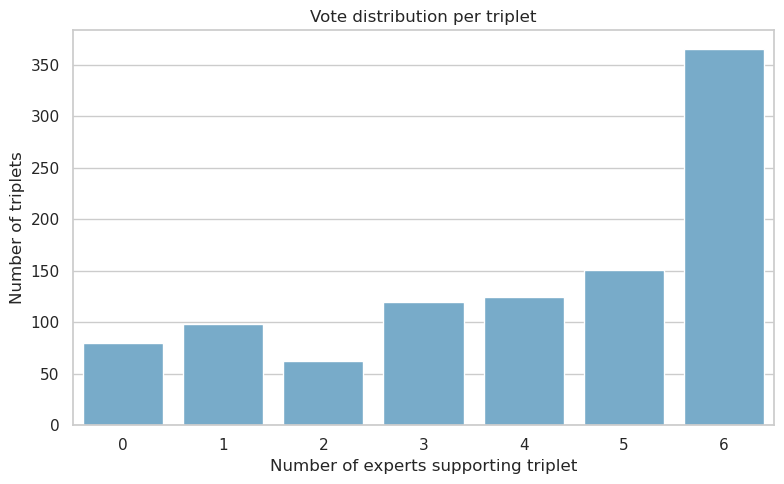

In [60]:
# 4️⃣ Vote distribution per triplet
# -----------------------------
new_df['Votes'] = new_df[experts].sum(axis=1)

vote_counts = new_df['Votes'].value_counts().sort_index()

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.barplot(x=vote_counts.index, y=vote_counts.values, color="#6BAED6")
plt.xlabel("Number of experts supporting triplet")
plt.ylabel("Number of triplets")
plt.title("Vote distribution per triplet")
plt.tight_layout()
plt.show()

In [61]:
import pandas as pd
from itertools import combinations
from sklearn.metrics import cohen_kappa_score
import numpy as np

# List of experts
experts = [f'Expert_{i}' for i in range(1, 7)]

# Compute pairwise Cohen's kappa
pairwise_kappa = {}
for exp1, exp2 in combinations(experts, 2):
    kappa = cohen_kappa_score(new_df[exp1], new_df[exp2])
    pairwise_kappa[f'{exp1} vs {exp2}'] = kappa

pairwise_kappa_df = pd.DataFrame.from_dict(pairwise_kappa, orient='index', columns=['Cohen_kappa'])

# Compute average kappa
average_kappa = np.mean(list(pairwise_kappa.values()))

print("Pairwise Cohen's kappa between experts:")
print(pairwise_kappa_df)
print(f"\nAverage pairwise Cohen's kappa: {average_kappa:.3f}")

Pairwise Cohen's kappa between experts:
                      Cohen_kappa
Expert_1 vs Expert_2     0.292003
Expert_1 vs Expert_3     0.306682
Expert_1 vs Expert_4     0.597618
Expert_1 vs Expert_5     0.664992
Expert_1 vs Expert_6     0.515152
Expert_2 vs Expert_3     0.493881
Expert_2 vs Expert_4     0.456401
Expert_2 vs Expert_5     0.219548
Expert_2 vs Expert_6     0.595054
Expert_3 vs Expert_4     0.445754
Expert_3 vs Expert_5     0.206880
Expert_3 vs Expert_6     0.554217
Expert_4 vs Expert_5     0.471167
Expert_4 vs Expert_6     0.577465
Expert_5 vs Expert_6     0.363128

Average pairwise Cohen's kappa: 0.451


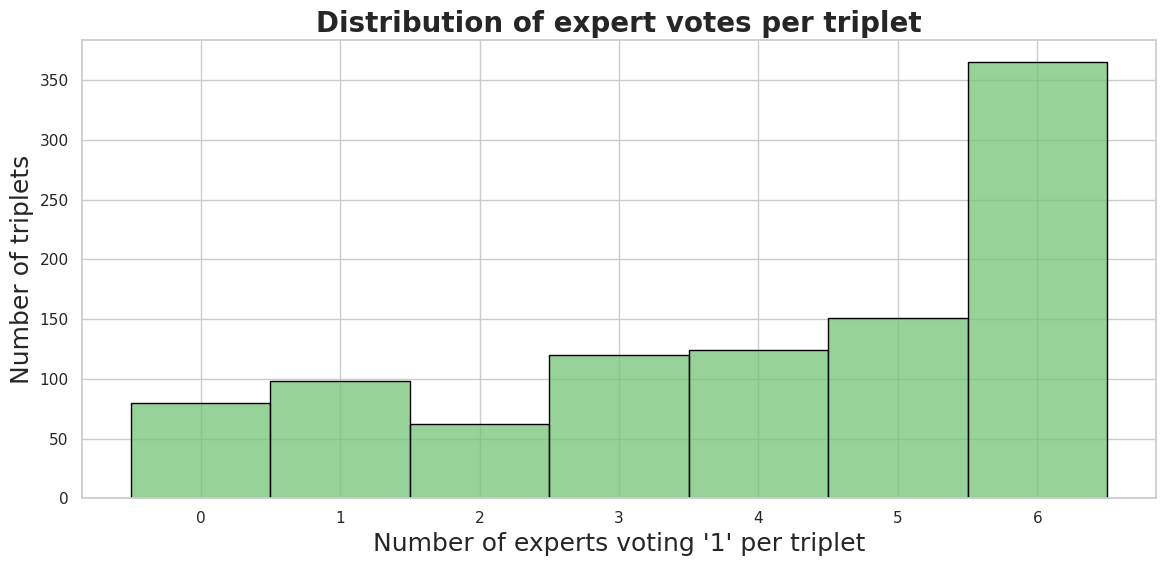

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Experts columns
experts = [f'Expert_{i}' for i in range(1, 7)]

# Count votes per triplet
vote_counts = new_df[experts].sum(axis=1)  # number of "1" votes per triplet

# Prepare plot style
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 18})

plt.figure(figsize=(12, 6))
sns.histplot(vote_counts, bins=range(0, 8), discrete=True, color='#74C476', edgecolor='black')

plt.xlabel("Number of experts voting '1' per triplet", fontsize=18)
plt.ylabel("Number of triplets", fontsize=18)
plt.title("Distribution of expert votes per triplet", fontsize=20, weight='bold')
plt.xticks(range(0, 7))
plt.tight_layout()
plt.savefig('./plots/experts_agreement.png', dpi=DPI, bbox_inches='tight')

plt.show()

In [70]:
# Fraction of 1s in Majority vote per Disaster Type + count
majority_fraction_by_disaster = (
    new_df
    .groupby('Disaster Type')
    .agg(
        Fraction_1=('Majority', 'mean'),
        N=('Majority', 'size')  # number of triplets per disaster type
    )
    .reset_index()
    .sort_values('Fraction_1', ascending=False)
)

majority_fraction_by_disaster

,Disaster Type,Fraction_1,N
12,Gas leak,1.000000,1
17,Miscellaneous accident (General),1.000000,1
13,Glacial lake outburst flood,1.000000,5
2,Collapse (Miscellaneous),0.818182,11
7,Explosion (Miscellaneous),0.812500,16
1,Collapse (Industrial),0.750000,4
21,Volcanic activity,0.750000,16
16,Mass movement (wet),0.743590,39
8,Extreme temperature,0.727273,11
23,Wildfire,0.675676,37


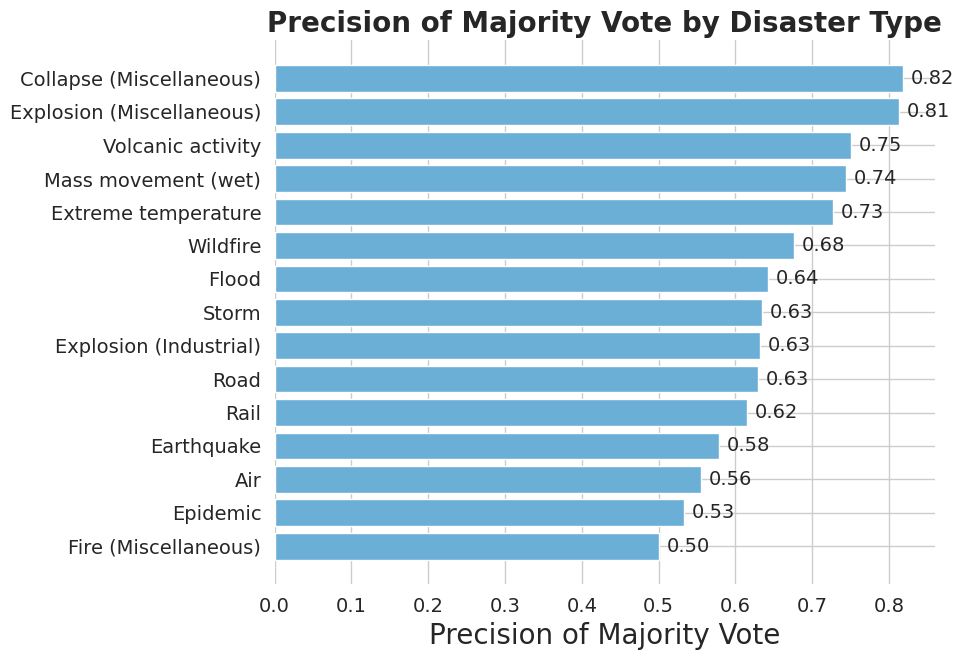

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare data ---
majority_fraction_filtered = (
    majority_fraction_by_disaster
    .query("N > 10")
    .sort_values("Fraction_1", ascending=True)  # for horizontal bar plot
)

# --- Plot styling ---
sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 20})
bar_color = '#6BAED6'  # pastel blue

# --- Plot ---
plt.figure(figsize=(10, 7))
ax = plt.barh(
    majority_fraction_filtered['Disaster Type'],
    majority_fraction_filtered['Fraction_1'],
    color=bar_color
)

# Labels
plt.xlabel('Precision of Majority Vote', fontsize=20)
plt.ylabel('')
plt.title('Precision of Majority Vote by Disaster Type', fontsize=20, weight='bold')

# Increase tick label sizes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Annotate bars with fraction
for i, row in majority_fraction_filtered.iterrows():
    plt.text(
        row['Fraction_1'] + 0.01,  # slightly offset
        row['Disaster Type'],
        f"{row['Fraction_1']:.2f}",
        va='center',
        fontsize=14
    )

# Clean look
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

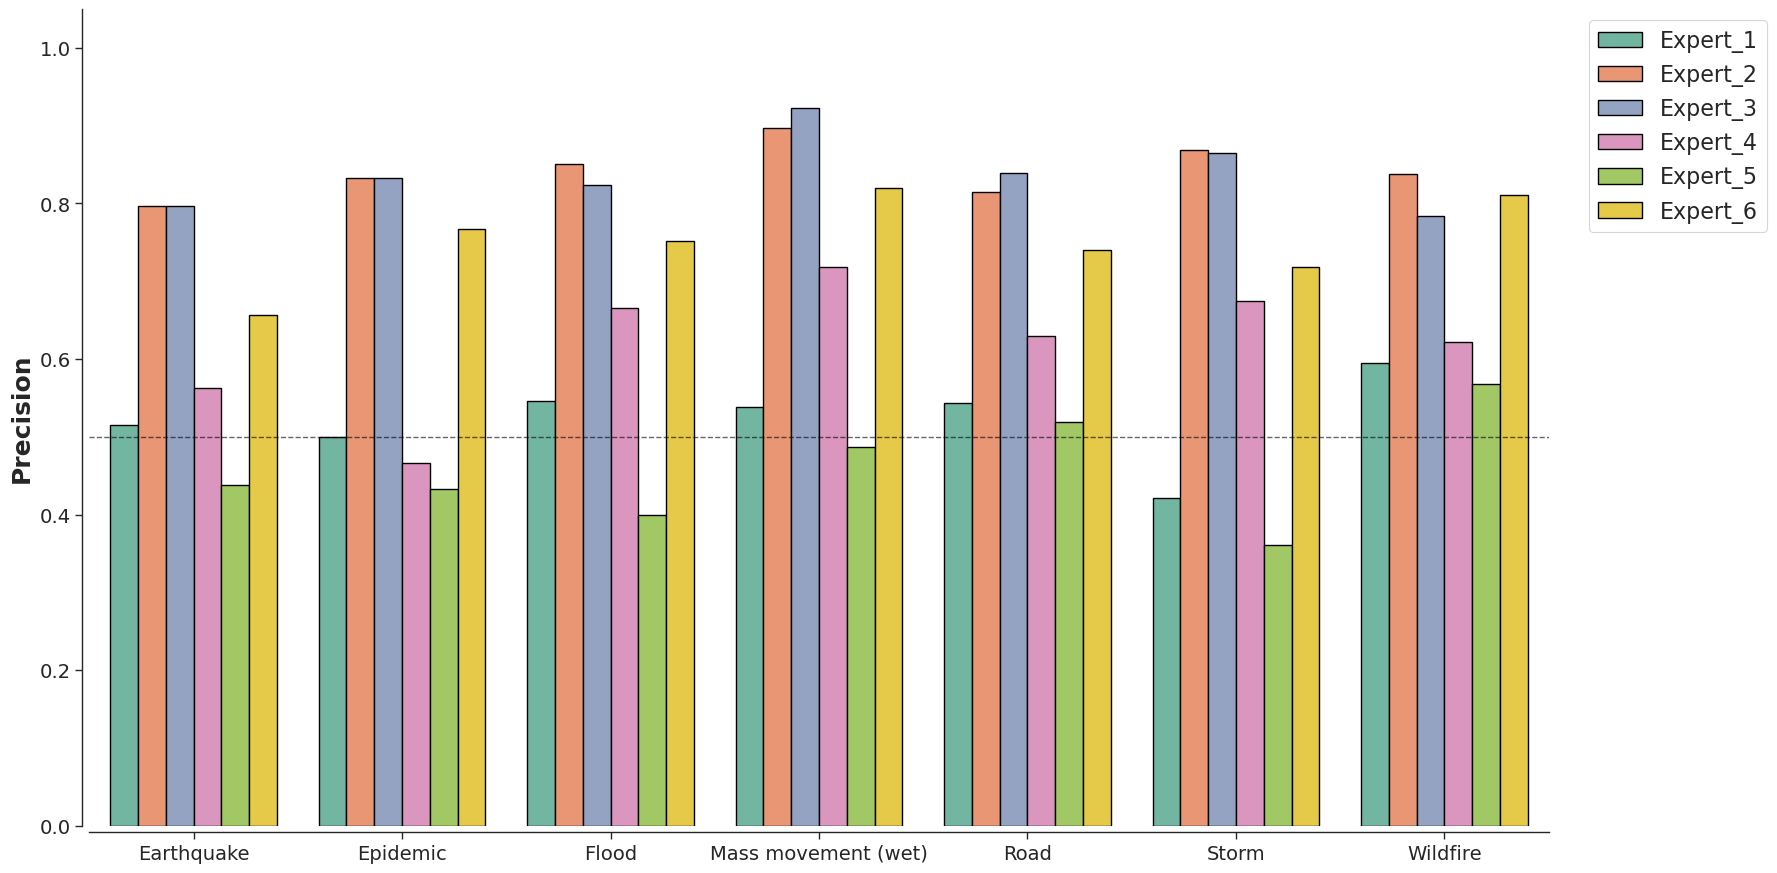

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Formatting Constants ---
FONT_SIZE_TITLE = 20
FONT_SIZE_AXIS = 18
FONT_SIZE_TICK = 18
FONT_SIZE_LEGEND = 16
DPI = 300
BAR_PALETTE = 'Set2'  # pastel colors

# --- List of expert columns ---
experts = [f'Expert_{i}' for i in range(1, 7)]

# --- Compute fraction of 1s per expert per disaster type ---
fractions_by_disaster = (
    new_df
    .groupby('Disaster Type')
    .agg(N=('Majority', 'size'), **{exp: (exp, 'mean') for exp in experts})
    .reset_index()
)

# Filter for N > 10
fractions_filtered = fractions_by_disaster.query("N > 20")

# Melt for Seaborn
plot_data = pd.melt(
    fractions_filtered,
    id_vars=['Disaster Type'],
    value_vars=experts,
    var_name='Expert',
    value_name='Fraction_1'
)

# --- Figure init ---
fig, ax = plt.subplots(figsize=(18, 9))
sns.set_context("paper", font_scale=1.6)
sns.set_style("ticks")

# --- Barplot ---
bar_plot = sns.barplot(
    x='Disaster Type',
    y='Fraction_1',
    hue='Expert',
    data=plot_data,
    palette=BAR_PALETTE,
    edgecolor='black',
    linewidth=1.0,
    ax=ax
)

# Labels & ticks
ax.set_ylabel('Precision', fontsize=FONT_SIZE_AXIS, fontweight='bold')
ax.set_xlabel('')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FONT_SIZE_TICK)
plt.yticks(fontsize=FONT_SIZE_TICK)
plt.xticks(fontsize=22)  # also increase here

ax.set_ylim(0, 1.05)

# Legend
leg = ax.legend(
    title='',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fontsize=FONT_SIZE_LEGEND
)

# Reference line at 0.5
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

# Despine
sns.despine(offset=5)

# Adjust layout
fig.subplots_adjust(bottom=0.25, right=0.85)
plt.tight_layout()

# Save figure
plt.savefig('./plots/triplet_fraction_experts.png', dpi=DPI, bbox_inches='tight')
plt.show()

In [60]:
new_df.to_csv("./data/triplet_validationDB_v2.csv", index = False)

In [28]:
new_df.to_csv("./data/triplet_validationDB.csv", index = False)

In [61]:
new_df.to_excel("./data/triplet_validationDB_v2.xlsx", index=False, engine='openpyxl')

In [31]:
new_df.iloc[0].Storyline

'An epidemic event related to the Nipah virus occurred in Bangladesh, with a total of 331 cases reported until January 2023. The exact locations mentioned are not specific to the January 2023 event but include Bangladesh as a whole, with the virus being endemic to the country High (given the high fatality rate of 236 deaths out of 331 cases The main cause of the disaster is the Nipah virus, a zoonotic virus transmitted from animals (specifically fruit bats) to humans, potentially through contaminated food or direct contact Economic damage: Unknown; People affected: 331 cases reported; Fatalities: 236 deaths; Effects on communities and infrastructure: Unknown Unknown Avoiding the consumption of raw date palm sap, as it can be contaminated with the virus, is recommended. Collaborative efforts between organizations like icddr,b and the Government of Bangladesh for surveillance, understanding disease transmission, and developing therapeutics and vaccines are also crucial Guidelines for aid

In [32]:
new_df.iloc[0]["gpt-oss-120b_sentence"]

'Supporting sentence(s):   "The main cause of the disaster is the Nipah virus, a zoonotic virus transmitted from animals (specifically fruit bats) to humans, potentially through contaminated food or direct contact."'

In [35]:
new_df.iloc[0]["mistral-small-3.2-24b_sentence"]

'- Supporting sentence(s): - "The main cause of the disaster is the Nipah virus"'

In [33]:
new_df

,Triplet,Disaster Type,Storyline,gpt-oss-120b_classification,gpt-oss-120b_sentence,llama-3.3-70b-instruct_classification,llama-3.3-70b-instruct_sentence,mistral-small-3.2-24b_classification,mistral-small-3.2-24b_sentence
0,"(nipah virus, causes, epidemic)",Epidemic,An epidemic event related to the Nipah virus o...,Deductible: True,"Supporting sentence(s): ""The main cause of t...",- Deductible: True,"- Supporting sentence(s): - ""An epidemic eve...",- Deductible: True,"- Supporting sentence(s): - ""The main cause of..."
1,"(flooding, causes, fatalities)",Storm,"A storm, Typhoon Kalmaegi, occurred in norther...",- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Fatalities: At ..."
2,"(heavy rain, causes, flooding)",Flood,Heavy rain and flooding hit Rio de Janeiro sta...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and ...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and fl..."
3,"(early intervention, prevents, casualties)",Flood,"A flood disaster occurred in South Africa, spe...",- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None
4,"(landslide, causes, economic damage)",Mass movement (wet),A landslide (Mass movement wet) occurred in Re...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""The economic da...",- Deductible: True,"- Supporting sentence(s): - ""The economic dama..."
...,...,...,...,...,...,...,...,...,...
995,"(flooding, causes, water-logging)",Storm,A storm event occurred in various locations in...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Effects on comm...",- Deductible: True,"- Supporting sentence(s): - ""Effects on co..."
996,"(low-pressure systems, causes, flooding)",Flood,"A flood disaster occurred in Australia, specif...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaste...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaster...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rainfall an..."
997,"(evacuation, prevents, casualties)",Storm,A super typhoon (Typhoon Nepartak) occurred in...,Deductible: True,"Supporting sentence(s): ""The government's en...",- Deductible: True,"- Supporting sentence(s): - ""The government'...",- Deductible: True,"- Supporting sentence(s): - ""The provincial go..."
998,"(floods, causes, economic damage)",Flood,Floods occurred in various regions of Indonesi...,- Deductible: True,"- Supporting sentence(s): - ""High Torrential...",- Deductible: True,"- Supporting sentence(s): - ""Economic damage...",- Deductible: True,"- Supporting sentence(s): - ""Economic damage: ..."


In [14]:
import pandas as pd

# Assuming `new_df` is your DataFrame

def compute_precision(df, classification_column):
    col = df[classification_column].fillna("")

    true_positives = col.str.contains('Deductible: True').sum()
    total_positives = col.str.contains('Deductible:').sum()

    return true_positives / total_positives if total_positives > 0 else 0

# Compute precision for each model
gpt_precision = compute_precision(new_df, 'gpt-oss-120b_classification')
llama_precision = compute_precision(new_df, 'llama-3.3-70b-instruct_classification')
mistral_precision = compute_precision(new_df, 'mistral-small-3.2-24b_classification')
gpt4_precision = compute_precision(new_df, 'gpt-4o_classification')
minimax_precision = compute_precision(new_df, 'minimax-m2_classification')

# Print precision values
print(f"Precision for GPT-OSS-120B: {gpt_precision}")
print(f"Precision for LLAMA-3.3-70B-Instruct: {llama_precision}")
print(f"Precision for Mistral-Small-3.2-24B: {mistral_precision}")
print(f"Precision for GPT-4o: {gpt4_precision}")
print(f"Precision for Minimax-m2: {minimax_precision}")


Precision for GPT-OSS-120B: 0.51
Precision for LLAMA-3.3-70B-Instruct: 0.853
Precision for Mistral-Small-3.2-24B: 0.835506519558676
Precision for GPT-4o: 0.6492985971943888
Precision for Minimax-m2: 0.42592592592592593


In [64]:
compute_precision(new_df, 'human_classification')

0.75

In [16]:
import pandas as pd

# Assuming `new_df` is your DataFrame

def majority_voting(row):
    true_count = sum([
        'Deductible: True' in str(row['gpt-oss-120b_classification']),
        'Deductible: True' in str(row['llama-3.3-70b-instruct_classification']),
        'Deductible: True' in str(row['mistral-small-3.2-24b_classification']),
        'Deductible: True' in str(row['gpt-4o_classification']),
        'Deductible: True' in str(row['minimax-m2_classification']),
    ])

    return 'Deductible: True' if true_count >= 2 else 'Deductible: False'

# Apply the majority voting function to each row and create a new column
new_df['majority_vote'] = new_df.apply(majority_voting, axis=1)


In [17]:

# Compute precision for the majority vote
majority_vote_precision = compute_precision(new_df, 'majority_vote')

# Print precision value
print(f"Precision for Majority Vote: {majority_vote_precision}")


Precision for Majority Vote: 0.802


In [42]:
new_df

,Triplet,Disaster Type,Storyline,gpt-oss-120b_classification,gpt-oss-120b_sentence,llama-3.3-70b-instruct_classification,llama-3.3-70b-instruct_sentence,mistral-small-3.2-24b_classification,mistral-small-3.2-24b_sentence,majority_vote
0,"(nipah virus, causes, epidemic)",Epidemic,An epidemic event related to the Nipah virus o...,Deductible: True,"Supporting sentence(s): ""The main cause of t...",- Deductible: True,"- Supporting sentence(s): - ""An epidemic eve...",- Deductible: True,"- Supporting sentence(s): - ""The main cause of...",Deductible: True
1,"(flooding, causes, fatalities)",Storm,"A storm, Typhoon Kalmaegi, occurred in norther...",- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Fatalities: At ...",Deductible: False
2,"(heavy rain, causes, flooding)",Flood,Heavy rain and flooding hit Rio de Janeiro sta...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and ...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and fl...",Deductible: True
3,"(early intervention, prevents, casualties)",Flood,"A flood disaster occurred in South Africa, spe...",- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,Deductible: False
4,"(landslide, causes, economic damage)",Mass movement (wet),A landslide (Mass movement wet) occurred in Re...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""The economic da...",- Deductible: True,"- Supporting sentence(s): - ""The economic dama...",Deductible: True
...,...,...,...,...,...,...,...,...,...,...
995,"(flooding, causes, water-logging)",Storm,A storm event occurred in various locations in...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Effects on comm...",- Deductible: True,"- Supporting sentence(s): - ""Effects on co...",Deductible: True
996,"(low-pressure systems, causes, flooding)",Flood,"A flood disaster occurred in Australia, specif...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaste...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaster...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rainfall an...",Deductible: True
997,"(evacuation, prevents, casualties)",Storm,A super typhoon (Typhoon Nepartak) occurred in...,Deductible: True,"Supporting sentence(s): ""The government's en...",- Deductible: True,"- Supporting sentence(s): - ""The government'...",- Deductible: True,"- Supporting sentence(s): - ""The provincial go...",Deductible: True
998,"(floods, causes, economic damage)",Flood,Floods occurred in various regions of Indonesi...,- Deductible: True,"- Supporting sentence(s): - ""High Torrential...",- Deductible: True,"- Supporting sentence(s): - ""Economic damage...",- Deductible: True,"- Supporting sentence(s): - ""Economic damage: ...",Deductible: True


In [ ]:
import pandas as pd

models = {
    'gpt-oss-120b': 'gpt-oss-120b_classification',
    'llama-3.3-70b-instruct': 'llama-3.3-70b-instruct_classification',
    'mistral-small-3.2-24b': 'mistral-small-3.2-24b_classification',
    'gpt-4o': 'gpt-4o_classification',
    'minimax-m2': 'minimax-m2_classification',
    'majority_vote': 'majority_vote'
}

def compute_precision_by_group(group, classification_column):
    col = group[classification_column].fillna("")

    true_positives = (col == 'Deductible: True').sum()
    total_positives = col.str.contains('Deductible:', na=False).sum()

    return true_positives / total_positives if total_positives > 0 else 0


precision_by_disaster_type = {}

for disaster_type, group in new_df.groupby('Disaster Type'):
    precision_by_disaster_type[disaster_type] = {
        model: compute_precision_by_group(group, col)
        for model, col in models.items()
    }

# Print results
for disaster_type, precisions in precision_by_disaster_type.items():
    print(f"\nDisaster Type: {disaster_type}")
    for model, precision in precisions.items():
        print(f"  {model} Precision: {precision:.3f}")



Disaster Type: Air
  gpt-oss-120b Precision: 0.167
  llama-3.3-70b-instruct Precision: 0.000
  mistral-small-3.2-24b Precision: 0.000
  gpt-4o Precision: 0.000
  minimax-m2 Precision: 0.111
  majority_vote Precision: 0.722

Disaster Type: Collapse (Industrial)
  gpt-oss-120b Precision: 0.250
  llama-3.3-70b-instruct Precision: 0.000
  mistral-small-3.2-24b Precision: 0.000
  gpt-4o Precision: 0.000
  minimax-m2 Precision: 0.000
  majority_vote Precision: 1.000

Disaster Type: Collapse (Miscellaneous)
  gpt-oss-120b Precision: 0.091
  llama-3.3-70b-instruct Precision: 0.000
  mistral-small-3.2-24b Precision: 0.000
  gpt-4o Precision: 0.000
  minimax-m2 Precision: 0.091
  majority_vote Precision: 0.909

Disaster Type: Drought
  gpt-oss-120b Precision: 0.000
  llama-3.3-70b-instruct Precision: 0.000
  mistral-small-3.2-24b Precision: 0.000
  gpt-4o Precision: 0.000
  minimax-m2 Precision: 0.000
  majority_vote Precision: 0.857

Disaster Type: Earthquake
  gpt-oss-120b Precision: 0.078
  

In [21]:
def compute_precision_by_group(group, classification_column):
    true_positives = group[
        group[classification_column].str.contains('Deductible: True', na=False)
    ].shape[0]

    total_positives = group[
        group[classification_column].str.contains('Deductible:', na=False)
    ].shape[0]

    precision = true_positives / total_positives if total_positives > 0 else 0
    return precision


In [22]:
precision_by_disaster_type_recheck = {}

for disaster_type, group in new_df.groupby('Disaster Type'):
    precision_by_disaster_type_recheck[disaster_type] = {
        'llama-3.3-70b-instruct': compute_precision_by_group(group, 'llama-3.3-70b-instruct_classification')
    }

for disaster_type, precision in precision_by_disaster_type_recheck.items():
    print(f"Rechecked Precision for {disaster_type} (LLAMA): {precision['llama-3.3-70b-instruct']}")


Rechecked Precision for Air (LLAMA): 0.7222222222222222
Rechecked Precision for Collapse (Industrial) (LLAMA): 0.75
Rechecked Precision for Collapse (Miscellaneous) (LLAMA): 0.9090909090909091
Rechecked Precision for Drought (LLAMA): 1.0
Rechecked Precision for Earthquake (LLAMA): 0.796875
Rechecked Precision for Epidemic (LLAMA): 0.8333333333333334
Rechecked Precision for Explosion (Industrial) (LLAMA): 0.8947368421052632
Rechecked Precision for Explosion (Miscellaneous) (LLAMA): 0.9375
Rechecked Precision for Extreme temperature (LLAMA): 0.9090909090909091
Rechecked Precision for Fire (Industrial) (LLAMA): 0.7142857142857143
Rechecked Precision for Fire (Miscellaneous) (LLAMA): 0.8
Rechecked Precision for Flood (LLAMA): 0.8507462686567164
Rechecked Precision for Gas leak (LLAMA): 1.0
Rechecked Precision for Glacial lake outburst flood (LLAMA): 1.0
Rechecked Precision for Industrial accident (General) (LLAMA): 1.0
Rechecked Precision for Mass movement (dry) (LLAMA): 1.0
Rechecked Prec

In [30]:
import pandas as pd

hum_df = pd.read_excel("./data/triplet_validationDB_hum.xlsx")

# Inspect to be safe
print(hum_df.columns)
print(len(hum_df))

Index(['Triplet', 'Disaster Type', 'Storyline', 'gpt-oss-120b_classification',
       'gpt-oss-120b_sentence', 'llama-3.3-70b-instruct_classification',
       'llama-3.3-70b-instruct_sentence',
       'mistral-small-3.2-24b_classification',
       'mistral-small-3.2-24b_sentence', 'majority_vote',
       'human_classification'],
      dtype='object')
1000


In [38]:
new_df['human_classification'] = hum_df['human_classification'].values
new_df['human_classification'] = new_df['human_classification'].apply(lambda x: 'Deductible: '+str(x))

In [39]:
new_df

,Triplet,Disaster Type,Storyline,gpt-oss-120b_classification,gpt-oss-120b_sentence,llama-3.3-70b-instruct_classification,llama-3.3-70b-instruct_sentence,mistral-small-3.2-24b_classification,mistral-small-3.2-24b_sentence,gpt-4o_classification,gpt-4o_sentence,minimax-m2_classification,minimax-m2_sentence,majority_vote,human_classification
0,"('nipah virus', 'causes', 'epidemic')",Epidemic,An epidemic event related to the Nipah virus o...,Deductible: True,"Supporting sentence(s): ""The main cause of t...",- Deductible: True,"- Supporting sentence(s): - ""An epidemic eve...",- Deductible: True,"- Supporting sentence(s): - ""The main cause of...",- Deductible: True,"- Supporting sentence(s): - ""An epidemic eve...",Deductible: True,"Supporting sentence(s): - ""An epidemic event...",Deductible: True,Deductible: True
1,"('flooding', 'causes', 'fatalities')",Storm,"A storm, Typhoon Kalmaegi, occurred in norther...",- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Fatalities: At ...",- Deductible: False,- Supporting sentence(s): None,Deductible: False,Supporting sentence(s): None ### Explanatio...,Deductible: False,Deductible: False
2,"('heavy rain', 'causes', 'flooding')",Flood,Heavy rain and flooding hit Rio de Janeiro sta...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and ...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and fl...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rain and ...",**Deductible:** False,**Supporting sentence(s):** None **Explanatio...,Deductible: True,Deductible: False
3,"('early intervention', 'prevents', 'casualties')",Flood,"A flood disaster occurred in South Africa, spe...",- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,- Deductible: False,- Supporting sentence(s): None,Deductible: False,Deductible: False
4,"('landslide', 'causes', 'economic damage')",Mass movement (wet),A landslide (Mass movement wet) occurred in Re...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""The economic da...",- Deductible: True,"- Supporting sentence(s): - ""The economic dama...",- Deductible: True,"- Supporting sentence(s): - ""The economic da...",- Deductible: False,- Supporting sentence(s): None,Deductible: True,Deductible: True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"('flooding', 'causes', 'water-logging')",Storm,A storm event occurred in various locations in...,- Deductible: False,- Supporting sentence(s): None,- Deductible: True,"- Supporting sentence(s): - ""Effects on comm...",- Deductible: True,"- Supporting sentence(s): - ""Effects on co...",- Deductible: True,"- Supporting sentence(s): - ""Effects on comm...",- Deductible: False,- Supporting sentence(s): None The storyline ...,Deductible: True,Deductible: False
996,"('low-pressure systems', 'causes', 'flooding')",Flood,"A flood disaster occurred in Australia, specif...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaste...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaster...",- Deductible: True,"- Supporting sentence(s): - ""Heavy rainfall an...",- Deductible: True,"- Supporting sentence(s): - ""A flood disaste...",- Deductible: False,- Supporting sentence(s): None The storylin...,Deductible: True,Deductible: True
997,"('evacuation', 'prevents', 'casualties')",Storm,A super typhoon (Typhoon Nepartak) occurred in...,Deductible: True,"Supporting sentence(s): ""The government's en...",- Deductible: True,"- Supporting sentence(s): - ""The government'...",- Deductible: True,"- Supporting sentence(s): - ""The provincial go...",- Deductible: True,"- Supporting sentence(s): - ""Unknown, but th...",Deductible: Tr

In [33]:
models["human"] = 'human_classification'

In [40]:
precision_df = (
    new_df
    .groupby('Disaster Type')
    .apply(lambda g: pd.Series({
        model: compute_precision_by_group(g, col)
        for model, col in models.items()
    }))
    .reset_index()
)

/tmp/ipykernel_137/3701537556.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [46]:
precision_df.human.mean()

0.8224274429365339

In [42]:
# Count entries per disaster type
disaster_counts = new_df['Disaster Type'].value_counts()

# Keep only disaster types with >= 20 samples
valid_disasters = disaster_counts[disaster_counts >= 20].index.tolist()

print(f"Keeping {len(valid_disasters)} disaster types with ≥20 entries:")
print(valid_disasters)

Keeping 8 disaster types with ≥20 entries:
['Flood', 'Storm', 'Road', 'Earthquake', 'Mass movement (wet)', 'Wildfire', 'Epidemic', 'Fire (Miscellaneous)']


In [43]:
precision_df_filtered = precision_df[
    precision_df['Disaster Type'].isin(valid_disasters)
].copy()

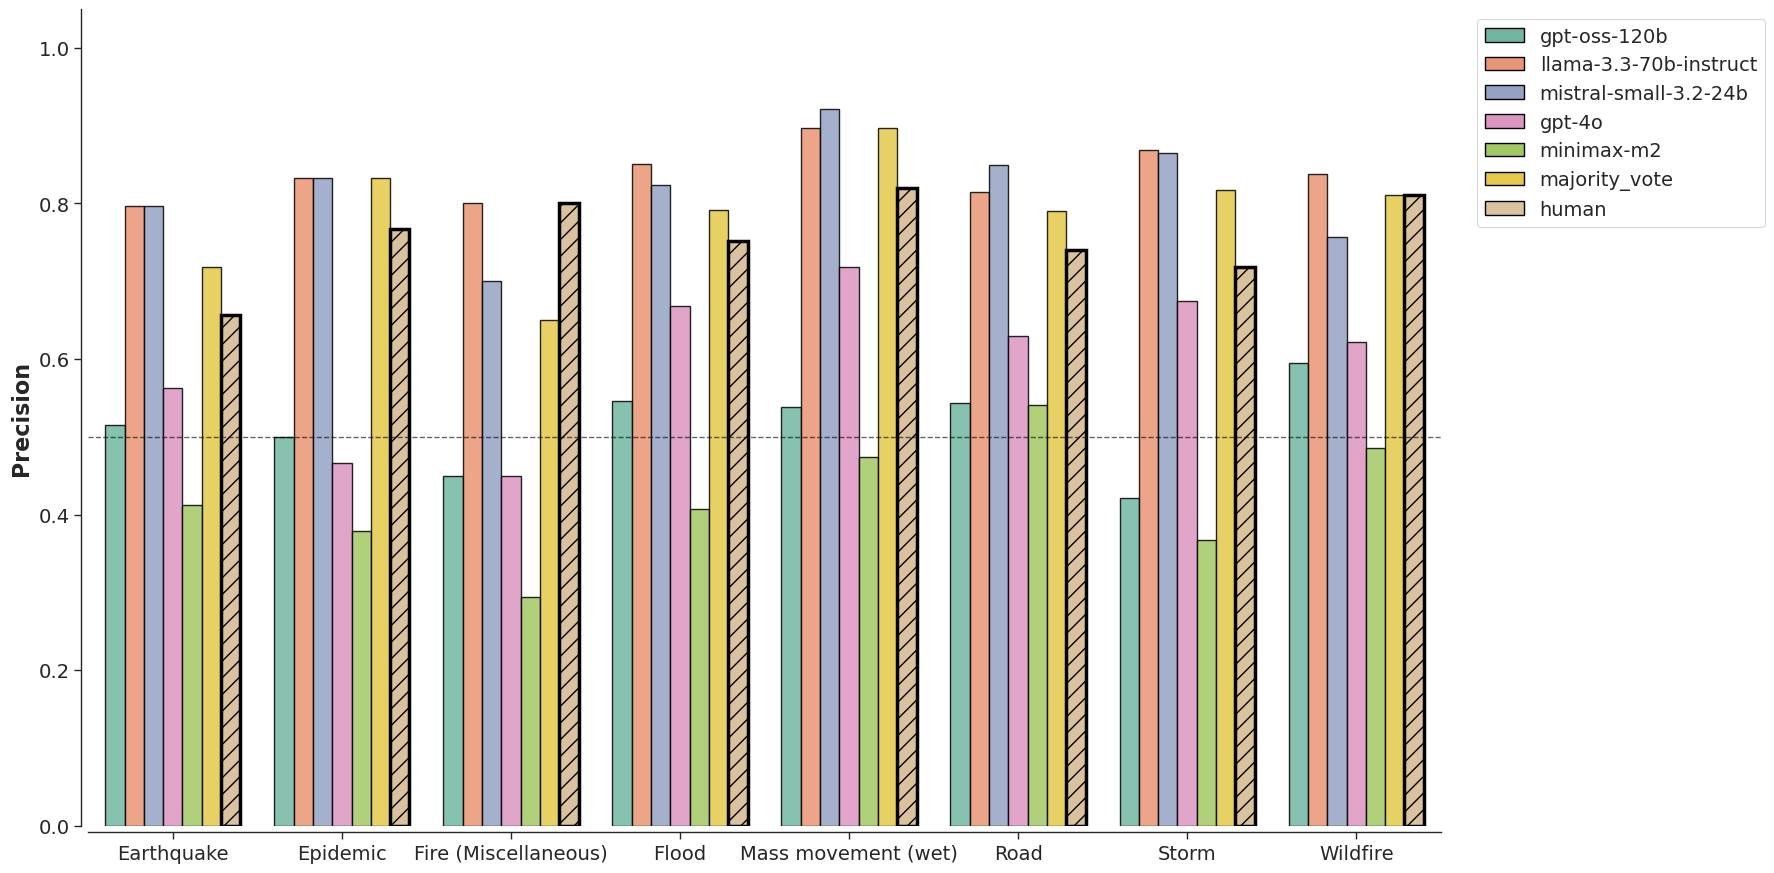

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Formatting Constants ---
FONT_SIZE_TITLE = 20
FONT_SIZE_AXIS = 16
FONT_SIZE_TICK = 14
FONT_SIZE_LEGEND = 14
DPI = 300

# Melt data for Seaborn
plot_data = pd.melt(
    precision_df_filtered,
    id_vars=['Disaster Type'],
    var_name='Model',
    value_name='Precision Score'
)

# Figure init: wider for many categories
fig, ax = plt.subplots(figsize=(18, 9))
sns.set_context("paper", font_scale=1.6)
sns.set_style("ticks")

# Barplot
bar_plot = sns.barplot(
    x='Disaster Type',
    y='Precision Score',
    hue='Model',
    data=plot_data,
    palette='Set2',
    edgecolor='black',
    linewidth=1.0,
    ax=ax
)

# Highlight HUMAN bars
for bar, (_, row) in zip(ax.patches, plot_data.iterrows()):
    if row['Model'].lower() == 'human':
        bar.set_edgecolor('black')
        bar.set_linewidth(2.5)
        bar.set_hatch('//')
        bar.set_alpha(1.0)
    else:
        bar.set_alpha(0.85)

# Labels & ticks
ax.set_ylabel('Precision', fontsize=FONT_SIZE_AXIS, fontweight='bold')
ax.set_xlabel('')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=FONT_SIZE_TICK)
plt.yticks(fontsize=FONT_SIZE_TICK)
ax.set_ylim(0, 1.05)

# Legend
leg = ax.legend(
    title='',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    fontsize=FONT_SIZE_LEGEND
)

# Reference line
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

# Despine
sns.despine(offset=5)

# Adjust layout to prevent clipping
fig.subplots_adjust(bottom=0.25, right=0.85)

plt.tight_layout()

plt.savefig('triplet_precision.png', dpi=DPI, bbox_inches='tight')
#plt.savefig('disaster_precision_analysis_highlight_human.pdf', bbox_inches='tight')
plt.show()